In [1]:
import pandas as pd
import numpy as np
import os
from tqdm.notebook import tqdm
import pickle
import networkx as nx
import collections


In [2]:
#read training data
nyc_train = pd.read_csv("../data/processed/training_data_city_nyc-full__trainWindow_210__.csv", index_col=0)
tky_train = pd.read_csv("../data/processed/training_data_city_tky-full__trainWindow_210__.csv", index_col=0)
nyc_train.head(2)

,uid,lat,lng,venueID,venue_descr,time,city_name,First_Category,Second_Category
0,1,40.717888,-74.005668,33236,Mexican Restaurant,2012-04-13 15:41:41+00:00,New York City,Dining and Drinking,Restaurant
1,1,40.733763,-74.006264,791,Diner,2012-04-20 01:49:26+00:00,New York City,Dining and Drinking,Restaurant


In [3]:
nyc_train["time"] = pd.to_datetime(nyc_train["time"])
nyc_train["time"].max()

Timestamp('2012-10-30 17:59:24+0000', tz='UTC')

In [4]:
nyc_train["time"] = pd.to_datetime(nyc_train["time"])
nyc_start_date = nyc_train["time"].min()
print("NYC start date:", nyc_start_date)
#the epoch is the date - the start date module 7 days
nyc_train["epoch"] = (nyc_train["time"] - nyc_start_date).dt.days // 7
nyc_train["epoch"] = nyc_train["epoch"].astype(int)
tky_train["time"] = pd.to_datetime(tky_train["time"])
tky_start_date = tky_train["time"].min()
#the epoch is the date - the start date module 7 days
tky_train["epoch"] = (tky_train["time"] - tky_start_date).dt.days // 7
tky_train["epoch"] = tky_train["epoch"].astype(int)

nyc_train

NYC start date: 2012-04-03 18:00:09+00:00


,uid,lat,lng,venueID,venue_descr,time,city_name,First_Category,Second_Category,epoch
0,1,40.717888,-74.005668,33236,Mexican Restaurant,2012-04-13 15:41:41+00:00,New York City,Dining and Drinking,Restaurant,1
1,1,40.733763,-74.006264,791,Diner,2012-04-20 01:49:26+00:00,New York City,Dining and Drinking,Restaurant,2
2,1,40.640856,-73.789201,6720,Steakhouse,2012-08-10 17:05:07+00:00,New York City,Dining and Drinking,Restaurant,18
5,1,40.722735,-74.010443,7469,Salon / Barbershop,2012-07-06 20:48:44+00:00,New York City,Business and Professional Services,Health and Beauty Service,13
6,1,40.776624,-73.979482,1328,Bar,2012-07-13 22:47:08+00:00,New York City,Dining and Drinking,Bar,14
...,...,...,...,...,...,...,...,...,...,...
166301,1083,40.732119,-73.985412,619,Bar,2012-05-16 04:22:00+00:00,New York City,Dining and Drinking,Bar,6
166302,1083,40.745270,-73.992309,6628,Hotel,2012-05-16 22:43:23+00:00,New York City,Travel and Transportation,Lodging,6
166303,1083,40.746445,-73.993921,4665,Deli / Bodega,2012-05-23 17:06:53+00:00,New York City,Dining and Drinking,Restaurant,7
166304,1083,40.744529,-73.991746,32129,Clothing Store,2012-05-30 00:14:33+00:00,New York City,Retail,Fashion Retail,8


<Axes: title={'center': 'NYC Second Category Frequency'}, xlabel='Second_Category'>

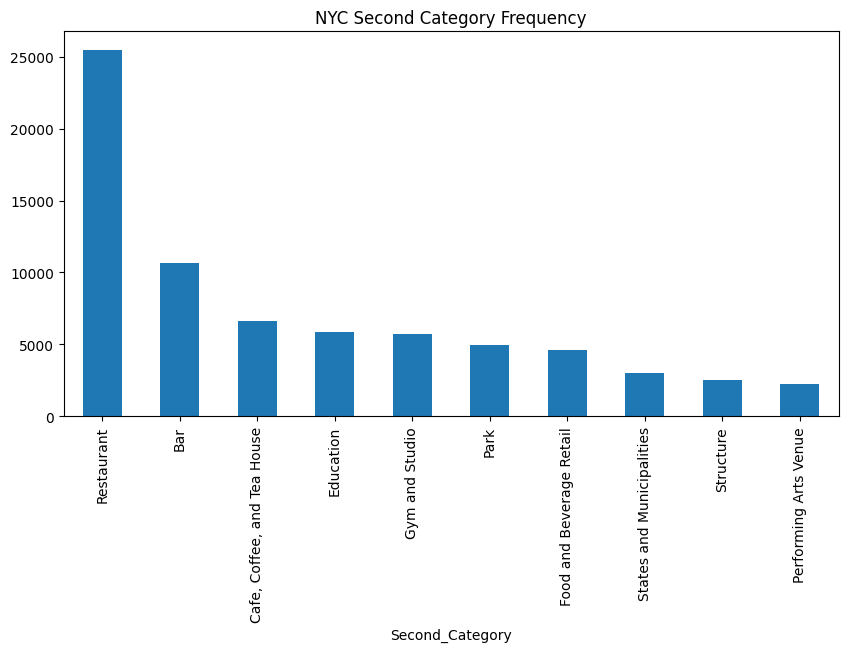

In [5]:
#plot of the frequency of the first 10 most common Second_Category values
nyc_train["Second_Category"].value_counts().head(10).plot(kind="bar", figsize=(10, 5), title="NYC Second Category Frequency")


<Axes: title={'center': 'TKY Second Category Frequency'}, xlabel='Second_Category'>

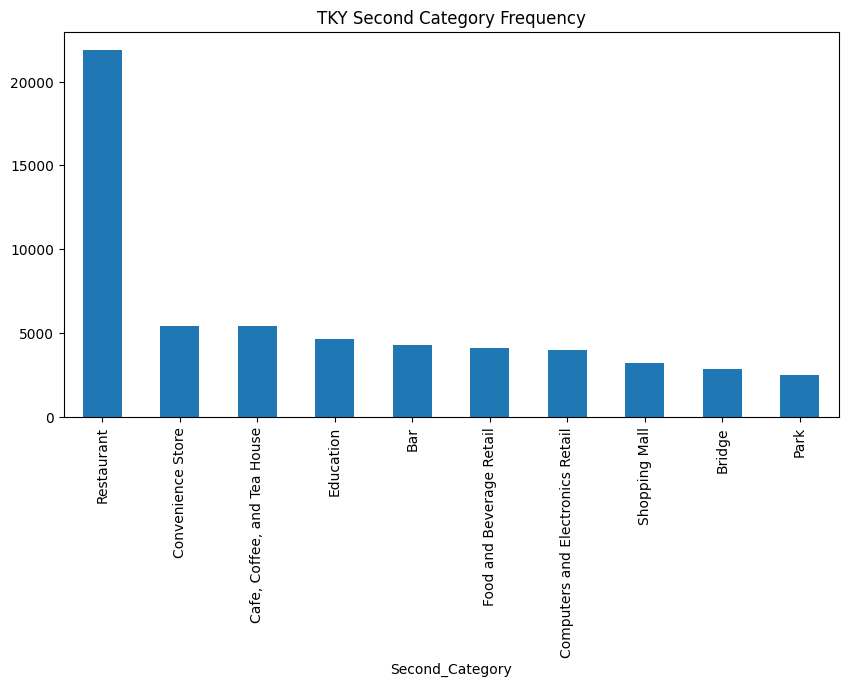

In [6]:
tky_train["Second_Category"].value_counts().head(10).plot(kind="bar", figsize=(10, 5), title="TKY Second Category Frequency")

In [7]:
sorted(list(tky_train["Second_Category"].unique()))

['Amusement Park',
 'Animal Shelter',
 'Antique Store',
 'Aquarium',
 'Arcade',
 'Art Gallery',
 'Arts and Crafts Store',
 'Arts and Entertainment',
 'Auditorium',
 'Automotive Retail',
 'Automotive Service',
 'Automotive Shop',
 'Bagel Shop',
 'Bakery',
 'Bar',
 'Baseball',
 'Beach',
 'Bike Rental',
 'Board Store',
 'Bookstore',
 'Boutique',
 'Bowling Alley',
 'Breakfast Spot',
 'Brewery',
 'Bridge',
 'Business and Professional Services',
 'Cafe, Coffee, and Tea House',
 'Cafeteria',
 'Campground',
 'Casino',
 'Cemetery',
 'Child Care Service',
 'Comedy Club',
 'Computers and Electronics Retail',
 'Convenience Store',
 'Convention Center',
 'Cosmetics Store',
 'Dentist',
 'Department Store',
 'Design Studio',
 'Dessert Shop',
 'Distillery',
 'Donut Shop',
 'Education',
 'Emergency Service',
 'Event Space',
 'Eyecare Store',
 'Factory',
 'Fair',
 'Farm',
 'Fashion Retail',
 'Field',
 'Financial Service',
 'Financial or Legal Service',
 'Flea Market',
 'Flower Store',
 'Food Court',
 'F

In [8]:
#Create the colocation networks of the training data.
#Two users are connected if they have at least one common POI in the same epoch. 
#One network is created. Two users must be connected at least once in the same epoch to be connected in the network.

def create_coloc_network(df):
    coloc_networks = {}
    for epoch in tqdm(df["epoch"].unique()):
        epoch_df = df[df["epoch"] == epoch]
        coloc_network = nx.Graph()
        for poi, group in epoch_df.groupby("venueID"):
            users = group["uid"].unique()
            if len(users) > 1:
                coloc_network.add_nodes_from(users)
                coloc_network.add_edges_from([(u, v) for u in users for v in users if u != v])
        coloc_networks[epoch] = coloc_network
    return coloc_networks

nyc_coloc_networks = create_coloc_network(nyc_train)
tky_coloc_networks = create_coloc_network(tky_train)

def collapse_temporal_networks(networks):
    networks = list(networks.values())
    G = networks[0].copy()
    for i in range(1, len(networks)):
        G = nx.compose(G, networks[i])
    return G

nyc_coloc_network = collapse_temporal_networks(nyc_coloc_networks)
tky_coloc_network = collapse_temporal_networks(tky_coloc_networks)


  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

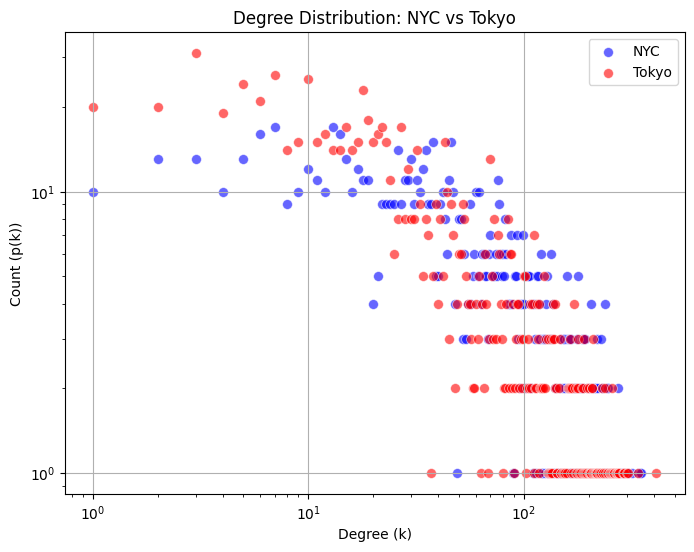

In [9]:
#plot degree distribution. k vs p(k). USE FUCKING POINTS not bars porcodio
import matplotlib.pyplot as plt
import seaborn as sns

def plot_degree_distribution_compare(G1, city1, G2, city2):
    degrees1 = [d for n, d in G1.degree()]
    degree_count1 = collections.Counter(degrees1)
    degree1, count1 = zip(*sorted(degree_count1.items()))
    
    degrees2 = [d for n, d in G2.degree()]
    degree_count2 = collections.Counter(degrees2)
    degree2, count2 = zip(*sorted(degree_count2.items()))
    
    plt.figure(figsize=(8, 6), dpi=100)
    sns.scatterplot(x=degree1, y=count1, s=50, color='blue', alpha=0.6, label=city1)
    sns.scatterplot(x=degree2, y=count2, s=50, color='red', alpha=0.6, label=city2)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Degree (k)')
    plt.ylabel('Count (p(k))')
    plt.title(f'Degree Distribution: {city1} vs {city2}')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_degree_distribution_compare(nyc_coloc_network, "NYC", tky_coloc_network, "Tokyo")


In [10]:
nx.density(nyc_coloc_network), nx.density(tky_coloc_network)

(0.06948460305542688, 0.05712047451177886)

In [11]:
n_nyc = nyc_coloc_network.number_of_nodes()
n_tky = tky_coloc_network.number_of_nodes()
m_nyc = nyc_coloc_network.number_of_edges()
m_tky = tky_coloc_network.number_of_edges()

In [12]:
n_nyc/n_tky*100, m_nyc/m_tky*100

(102.50965250965251, 127.83111285266457)

In [25]:
k_percentile = 1.5
nyc_degree = np.array([d for n, d in nyc_coloc_network.degree()])
tky_degree = np.array([d for n, d in tky_coloc_network.degree()])

#take the top k_percentile of the degree distribution
nyc_top_k = np.percentile(nyc_degree, 100 - k_percentile)
tky_top_k = np.percentile(tky_degree, 100 - k_percentile)

#count the number of nodes with degree greater than the top k percentile
nyc_top_k_count = np.sum(nyc_degree >= nyc_top_k)
tky_top_k_count = np.sum(tky_degree >= tky_top_k)
nyc_top_k_count, tky_top_k_count


(17, 16)

In [14]:
#calculate the density of the networks induced by the top k percentile of the degree distribution
def calculate_density(G, top_k):
    top_k_nodes = [n for n, d in G.degree() if d >= top_k]
    subgraph = G.subgraph(top_k_nodes)
    density = nx.density(subgraph)
    return density

nyc_density = calculate_density(nyc_coloc_network, nyc_top_k)
tky_density = calculate_density(tky_coloc_network, tky_top_k)
nyc_density, tky_density

(0.8457912457912458, 0.9374057315233786)

In [15]:
tky_top_k_count

52

In [16]:
import pathlib
seed = 500

### SET HYPERPARAMETERS ###
t_window = 210  # Training window in days
k_days = 7  # Epoch length in days
threshold = 100  # Performance degradation threshold (adjust as needed)
max_simulation_days = 104  # Maximum number of simulation days
topK = 20
version = "full"
### ------------------- ###


city = "nyc"
algorithm = "MultiVAE"

basedir = pathlib.Path().cwd().parent

# Define base directory up to the version level
version_dir = basedir / 'out' / 'experiments' / version

simulated_temporal_colocation_net = {}

# Iterate over seed directories (0,1,...) inside the version directory
for seed_dir in version_dir.iterdir():
    #ensure it's a directory and only a number
    if not seed_dir.is_dir() or not seed_dir.name.isdigit():
        continue
    

    # Extract seed from folder name
    s = int(seed_dir.name)
    if s != seed:
        continue

    print(seed)
    # Define the colocation network simulation path inside each seed folder
    colocation_network_simulated_dir = (
        seed_dir / 'colocationnetworks' /
        f'city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}'
    )

    if not colocation_network_simulated_dir.exists():
        continue  # Skip if the directory doesn't exist

    for file_path in tqdm(colocation_network_simulated_dir.iterdir()):
        if file_path.name.endswith(".gpickle"):
            rec_prob = float(file_path.name.split("_")[1])
            epoch = int(file_path.name.split("_")[3].split(".")[0])

            # Initialize dictionary structure
            if seed not in simulated_temporal_colocation_net:
                simulated_temporal_colocation_net[seed] = {}
            if rec_prob not in simulated_temporal_colocation_net[seed]:
                simulated_temporal_colocation_net[seed][rec_prob] = {}

            # Load the graph
            with open(file_path, "rb") as f:
                simulated_temporal_colocation_net[seed][rec_prob][epoch] = pickle.load(f)




# Define probability values in a list for easy reference
probabilities = [0.0]

# Create a dictionary to store all networks
colocation_nets = {p: simulated_temporal_colocation_net[seed][p] for p in probabilities}




def collapse_temporal_networks(networks):
    networks = list(networks.values())
    G = networks[0].copy()
    for i in range(1, len(networks)):
        G = nx.compose(G, networks[i])
    return G

agg_network_nyc = collapse_temporal_networks(colocation_nets[0.0])

500


0it [00:00, ?it/s]

In [17]:
import pathlib
seed = 500

### SET HYPERPARAMETERS ###
t_window = 210  # Training window in days
k_days = 7  # Epoch length in days
threshold = 100  # Performance degradation threshold (adjust as needed)
max_simulation_days = 104  # Maximum number of simulation days
topK = 20
version = "full"
### ------------------- ###


city = "tky"
algorithm = "MultiVAE"

basedir = pathlib.Path().cwd().parent

# Define base directory up to the version level
version_dir = basedir / 'out' / 'experiments' / version

simulated_temporal_colocation_net = {}

# Iterate over seed directories (0,1,...) inside the version directory
for seed_dir in version_dir.iterdir():
    #ensure it's a directory and only a number
    if not seed_dir.is_dir() or not seed_dir.name.isdigit():
        continue
    

    # Extract seed from folder name
    s = int(seed_dir.name)
    if s != seed:
        continue

    print(seed)
    # Define the colocation network simulation path inside each seed folder
    colocation_network_simulated_dir = (
        seed_dir / 'colocationnetworks' /
        f'city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}'
    )

    if not colocation_network_simulated_dir.exists():
        continue  # Skip if the directory doesn't exist

    for file_path in tqdm(colocation_network_simulated_dir.iterdir()):
        if file_path.name.endswith(".gpickle"):
            rec_prob = float(file_path.name.split("_")[1])
            epoch = int(file_path.name.split("_")[3].split(".")[0])

            # Initialize dictionary structure
            if seed not in simulated_temporal_colocation_net:
                simulated_temporal_colocation_net[seed] = {}
            if rec_prob not in simulated_temporal_colocation_net[seed]:
                simulated_temporal_colocation_net[seed][rec_prob] = {}

            # Load the graph
            with open(file_path, "rb") as f:
                simulated_temporal_colocation_net[seed][rec_prob][epoch] = pickle.load(f)




# Define probability values in a list for easy reference
probabilities = [0.0]

# Create a dictionary to store all networks
colocation_nets = {p: simulated_temporal_colocation_net[seed][p] for p in probabilities}




def collapse_temporal_networks(networks):
    networks = list(networks.values())
    G = networks[0].copy()
    for i in range(1, len(networks)):
        G = nx.compose(G, networks[i])
    return G

agg_network_tky = collapse_temporal_networks(colocation_nets[0.0])

500


0it [00:00, ?it/s]

In [18]:
#take the top k percentile of the degree distribution
k_percentile = 1.82
nyc_degree = np.array([d for n, d in agg_network_nyc.degree()])
tky_degree = np.array([d for n, d in agg_network_tky.degree()])

#take the top k_percentile of the degree distribution
nyc_top_k = np.percentile(nyc_degree, 100 - k_percentile)
tky_top_k = np.percentile(tky_degree, 100 - k_percentile)

#count the number of nodes with degree greater than the top k percentile
nyc_top_k_count = np.sum(nyc_degree >= nyc_top_k)
tky_top_k_count = np.sum(tky_degree >= tky_top_k)
nyc_top_k_count, tky_top_k_count

(14, 16)

In [19]:
#calculate the density of the networks induced by the top k percentile of the degree distribution
def calculate_density(G, top_k):
    top_k_nodes = [n for n, d in G.degree() if d >= top_k]
    subgraph = G.subgraph(top_k_nodes)
    density = nx.density(subgraph)
    return density

nyc_density = calculate_density(agg_network_nyc, nyc_top_k)
tky_density = calculate_density(agg_network_tky, tky_top_k)
nyc_density, tky_density

(0.21978021978021978, 0.9166666666666666)

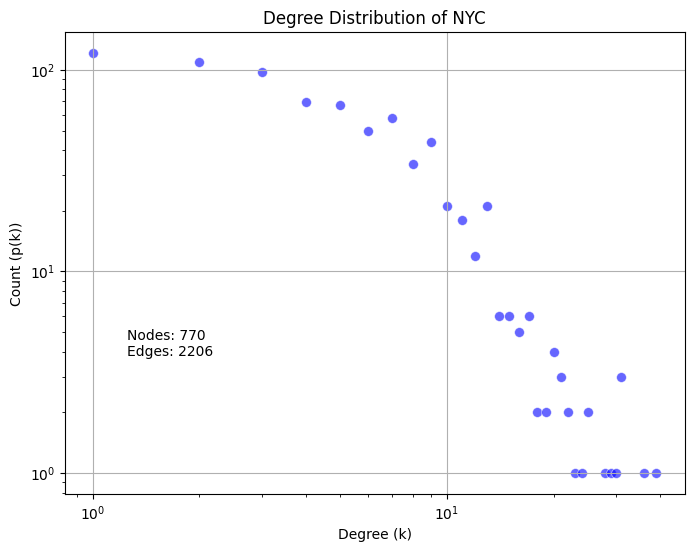

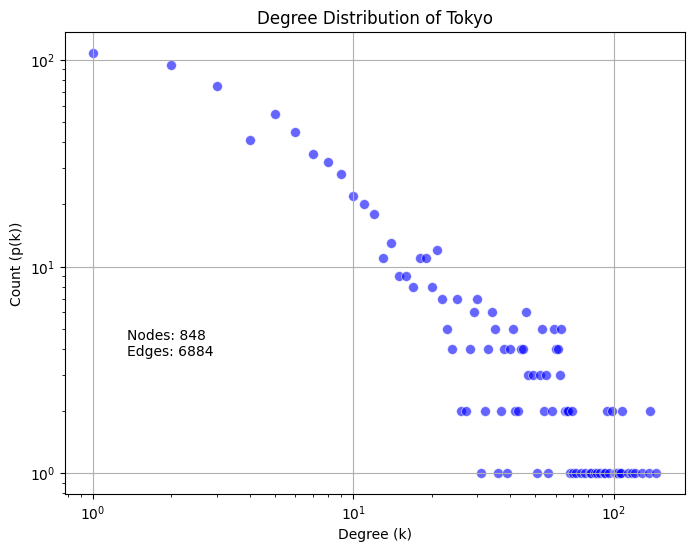

In [20]:
#plot the degree distribution of the top k percentile of the whole degree distribution of the coloc networks.
#Do it as a scatter plot with log-log scale. On the x-axis the degree and on the y-axis the frequency of the degree. Ignore topk
#on input nyc_degree, tky_degree: the degree distribution of the coloc networks

def plot_degree_distribution(degree_distribution, city_name, graph):
    degree_count = collections.Counter(degree_distribution)
    degree, count = zip(*sorted(degree_count.items()))
    
    plt.figure(figsize=(8, 6), dpi=100)
    sns.scatterplot(x=degree, y=count, s=50, color='blue', alpha=0.6)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Degree (k)')
    plt.ylabel('Count (p(k))')
    plt.title(f'Degree Distribution of {city_name}')
    # write the number of nodes and edges in the plot left corner
    plt.text(0.1, 0.3, f'Nodes: {graph.number_of_nodes()}\nEdges: {graph.number_of_edges()}', transform=plt.gca().transAxes)

    plt.grid(True)
    plt.show()
plot_degree_distribution(nyc_degree, "NYC", agg_network_nyc)
plot_degree_distribution(tky_degree, "Tokyo", agg_network_tky)

In [21]:
sorted(nyc_degree, reverse=True)[:10], sorted(tky_degree, reverse=True)[:10]

([39, 36, 31, 31, 31, 30, 29, 28, 25, 25],
 [146, 138, 138, 137, 129, 121, 118, 114, 108, 108])